In [1]:

!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [3]:
df = pd.read_csv("IMDB Dataset.csv")

print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [4]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

Dataset shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


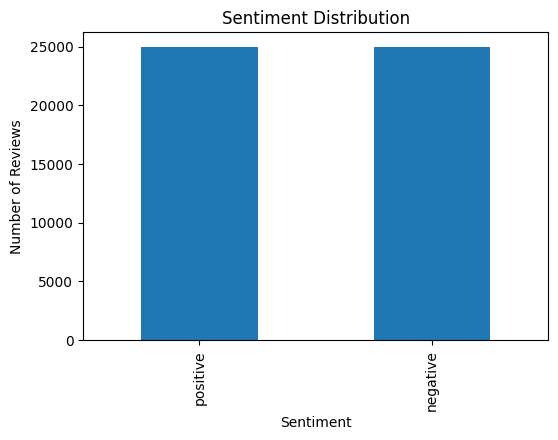

In [5]:
df['sentiment'].value_counts().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [6]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

print(df.head())

                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. <br /><br />The...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1


In [8]:
X = df['review'].values
y = df['sentiment'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000,)
y shape: (50000,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


In [11]:
max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 111959


In [12]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Original review:")
print(X_train[0])

print("\nConverted sequence:")
print(X_train_seq[0])

Original review:
I caught this little gem totally by accident back in 1980 or '81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch of sci-fi short spoofs (to get us in the mood). Most were somewhat amusing but THIS came on and, within seconds, the audience was in hysterics! The biggest laugh came when they showed "Princess Laia" having huge cinnamon buns instead of hair on her head. She looks at the camera, gives a grim smile and nods. That made it even funnier! You gotta see "Chewabacca" played by what looks like a Muppet! It was extremely silly and stupid...but I couldn't stop laughing. Most of the dialogue was drowned out because of all the laughter. Also if you know "Star Wars" pretty well it's even funnier--they deliberately poke fun at some of the dialogue. This REALLY works with an audience! A definite 10!

Converted sequence:
[11, 1055, 12, 120, 1506, 458, 32, 1609, 143, 9, 4301, 39, 1, 11, 14,

In [13]:
max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("X_train:", X_train_pad.shape)
print("X_test:", X_test_pad.shape)

X_train: (40000, 200)
X_test: (10000, 200)


In [14]:
model = Sequential()

model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_length
    )
)

model.add(
    LSTM(128)
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(1, activation='sigmoid')
)

model.summary()

c:\Users\shada\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 108ms/step - accuracy: 0.5397 - loss: 0.6850 - val_accuracy: 0.5226 - val_loss: 0.6854
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 110ms/step - accuracy: 0.5798 - loss: 0.6682 - val_accuracy: 0.5375 - val_loss: 0.6720
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 98ms/step - accuracy: 0.7957 - loss: 0.4441 - val_accuracy: 0.8606 - val_loss: 0.3401
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 103ms/step - accuracy: 0.8955 - loss: 0.2678 - val_accuracy: 0.8673 - val_loss: 0.3221
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 52s 104ms/step - accuracy: 0.9266 - loss: 0.2056 - val_accuracy: 0.8739 - val_loss: 0.3446


In [17]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8656 - loss: 0.3618
Test Loss: 0.36184874176979065
Test Accuracy: 0.8655999898910522


In [18]:
y_pred_probability = model.predict(X_test_pad)

print(y_pred_probability[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
[[0.03284038]
 [0.18334429]
 [0.97754824]
 [0.05182043]
 [0.01167885]
 [0.01025499]
 [0.69134426]
 [0.03723605]
 [0.03148105]
 [0.02763982]]


In [20]:
y_pred = (y_pred_probability >= 0.5).astype(int).flatten()

print("y_pred shape:", y_pred.shape)
print("y_pred first 10:", y_pred[:10])

y_pred shape: (10000,)
y_pred first 10: [0 0 1 0 0 0 1 0 0 0]


In [21]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Negative', 'Positive']
    )
)

              precision    recall  f1-score   support

    Negative       0.86      0.88      0.87      5000
    Positive       0.88      0.85      0.86      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [25]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4401  599]
 [ 745 4255]]


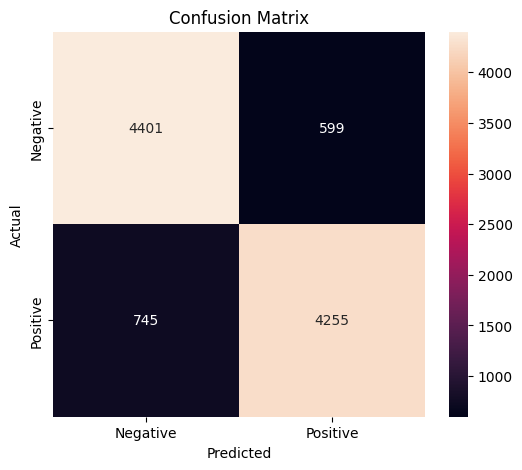

In [27]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

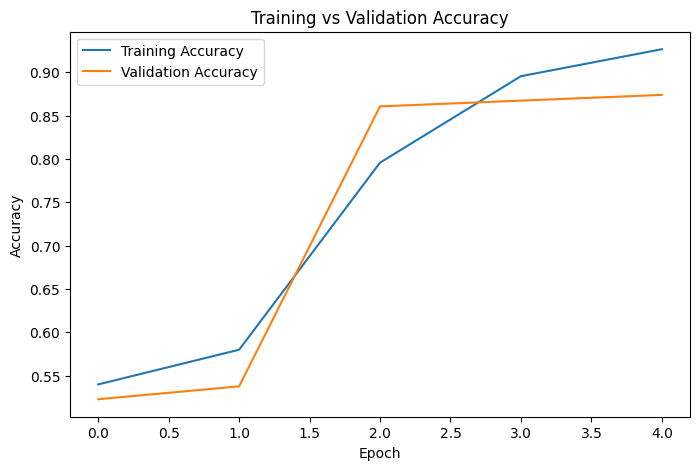

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

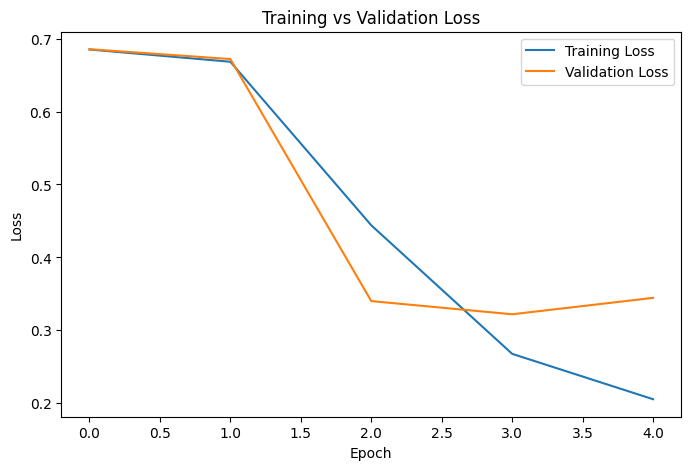

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [29]:
def predict_sentiment(review):

    sequence = tokenizer.texts_to_sequences([review])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    probability = model.predict(
        padded,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Sentiment:", sentiment)
    print("Probability:", probability)

In [32]:
predict_sentiment(
    "This movie was extremely boring and disappointing. "
    "The acting was terrible."
)

Review: This movie was extremely boring and disappointing. The acting was terrible.
Sentiment: Negative
Probability: 0.012891667


In [34]:
predict_sentiment(
    "This movie was absolutely amazing. "
    "The acting was excellent and the story was fantastic."
)

Review: This movie was absolutely amazing. The acting was excellent and the story was fantastic.
Sentiment: Positive
Probability: 0.9809766
